### Setup and Configuration

In [7]:
# CELL 1: Setup, Configuration, and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

# --- CONFIGURATION ---
# Automatically find the latest pipeline run via the pointer file
OUTPUT_ROOT = Path("./data/derived")
latest_run_ptr = OUTPUT_ROOT / "psycomark_latest.txt"

if not latest_run_ptr.exists():
    raise FileNotFoundError(f"Could not find pointer file at '{latest_run_ptr}'. Please run data_pipeline.py first.")

PIPELINE_OUTPUT_DIR = Path(latest_run_ptr.read_text().strip())
print(f"--- Loading data from latest pipeline run: {PIPELINE_OUTPUT_DIR.name} ---")

# --- Load Data and Manifest ---
train_df = pd.read_json(PIPELINE_OUTPUT_DIR / "train.jsonl", lines=True)
dev_df = pd.read_json(PIPELINE_OUTPUT_DIR / "dev.jsonl", lines=True)

with open(PIPELINE_OUTPUT_DIR / "manifest.json") as f:
    manifest = json.load(f)

# --- Report Key Stats from Manifest ---
print("\n=== Pipeline Run Summary ===")
sizes = manifest.get('sizes', {})
print(f"Train Set: {sizes.get('train_raw', 'N/A')} raw -> {sizes.get('train_final', 'N/A')} final")
print(f"  - Docs removed due to dev set leakage: {sizes.get('train_docs_removed_leakage', 'N/A')}")
print(f"  - Docs removed as internal duplicates: {sizes.get('train_docs_removed_internal_dups', 'N/A')}")
print(f"Dev Set:   {sizes.get('dev_raw', 'N/A')} raw -> {sizes.get('dev_final', 'N/A')} final (dev set is preserved)")
print("============================")


# --- Prepare Combined DataFrame for Analysis ---
train_df['split'] = 'train'
dev_df['split'] = 'dev'
df_all = pd.concat([train_df, dev_df], ignore_index=True)

# Recreate the spans dataframe for span-level analyses
span_rows = []
for _, row in df_all.iterrows():
    for m in (row["markers"] or []):
        if isinstance(m.get("start"), int) and isinstance(m.get("end"), int):
             span_rows.append({
                "doc_id": row["doc_id"], "label": m["label"],
                "start": m["start"], "end": m["end"],
                "char_len": m["end"] - m["start"]
             })
df_spans = pd.DataFrame(span_rows)

print("\nData loaded and prepared for analysis.")

--- Loading data from latest pipeline run: psycomark_official_split_20250928_232947 ---

=== Pipeline Run Summary ===
Train Set: 3682 raw -> 3360 final
  - Docs removed due to dev set leakage: 20
  - Docs removed as internal duplicates: N/A
Dev Set:   100 raw -> 100 final (dev set is preserved)

Data loaded and prepared for analysis.


### Mean IoU Matrix for Overlapping Spans

--- Calculating Mean IoU for Overlapping Spans ---

Mean IoU heatmap saved to C:\Users\panagiotis\Desktop\GitHub\PsyChoMark_Semeval\data\derived\psycomark_official_split_20250928_232947\mean_iou_matrix.png


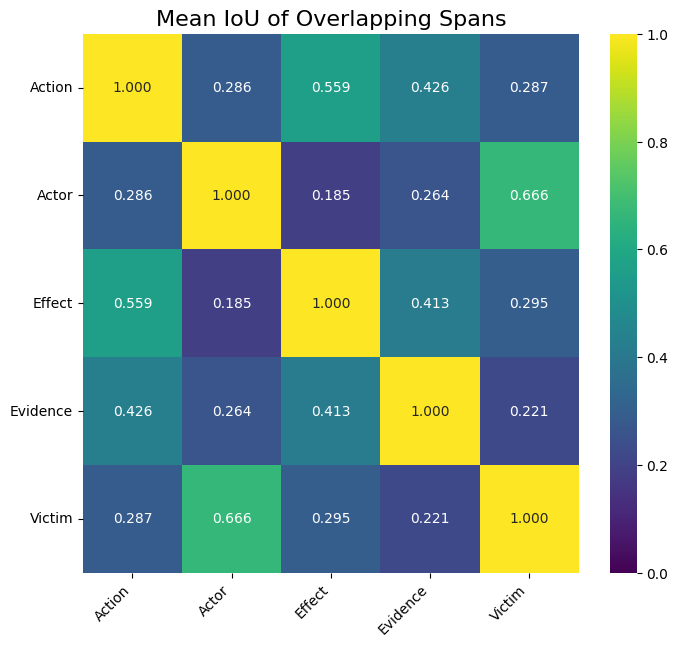


Top 3 Most Ambiguous (Overlapping) Marker Pairs:
- Actor <-> Victim: Mean IoU = 0.666 (based on 77 overlaps)
- Action <-> Effect: Mean IoU = 0.559 (based on 208 overlaps)
- Action <-> Evidence: Mean IoU = 0.426 (based on 190 overlaps)


In [8]:
# CELL 2: Mean IoU Matrix for Overlapping Spans
from collections import defaultdict
from typing import Tuple
import numpy as np

print("--- Calculating Mean IoU for Overlapping Spans ---")

# Helper function to calculate character-level IoU
def iou_char(a: Tuple[int,int], b: Tuple[int,int]) -> float:
    """Calculates Intersection over Union for two character spans."""
    inter_start = max(a[0], b[0])
    inter_end = min(a[1], b[1])
    inter = max(0, inter_end - inter_start)
    
    union = (a[1] - a[0]) + (b[1] - b[0]) - inter
    return inter / union if union > 0 else 0.0

# 1. Initialize data structures
# Use the constants loaded in the first cell or redefine them for clarity
ALLOWED_MARKERS = {"Actor", "Action", "Effect", "Victim", "Evidence"}
labels_sorted = sorted(list(ALLOWED_MARKERS))

sum_iou = defaultdict(float)
cnt_iou = defaultdict(int)

# 2. Iterate through all documents and their spans
for _, row in df_all.iterrows():
    # Filter for valid markers and sort by position for efficient pairing
    spans = sorted(
        [
            (m["label"], m["start"], m["end"]) 
            for m in (row["markers"] or []) 
            if m.get("label") in ALLOWED_MARKERS and isinstance(m.get("start"), int)
        ],
        key=lambda x: (x[1], x[2])
    )
    
    # Consider all unique pairs of spans within the document
    for i in range(len(spans)):
        li, si, ei = spans[i]
        for j in range(i + 1, len(spans)):
            lj, sj, ej = spans[j]
            
            # Efficient check for overlap: if the start of one is after the end of the other, they don't overlap.
            # The sorted list makes this even faster, as we can break early.
            if sj >= ei:
                break 

            # Calculate IoU for the overlapping pair
            iou = iou_char((si, ei), (sj, ej))
            if iou > 0:
                # Create a canonical key for the pair of labels (e.g., ('Action', 'Effect'))
                a, b = sorted([li, lj])
                key = (a, b)
                sum_iou[key] += iou
                cnt_iou[key] += 1

# 3. Construct the final matrix for plotting
mat = np.zeros((len(labels_sorted), len(labels_sorted)), dtype=float)

for i, a in enumerate(labels_sorted):
    for j, b in enumerate(labels_sorted):
        if i == j:
            mat[i, j] = 1.0  # A label has perfect IoU with itself
        else:
            key = tuple(sorted([a, b]))
            if cnt_iou[key] > 0:
                mat[i, j] = sum_iou[key] / cnt_iou[key]

# 4. Plot the heatmap
plt.figure(figsize=(8, 7))
sns.heatmap(
    mat, 
    annot=True, 
    fmt=".3f", 
    cmap="viridis", 
    xticklabels=labels_sorted, 
    yticklabels=labels_sorted,
    vmin=0,
    vmax=1
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Mean IoU of Overlapping Spans", fontsize=16)

# Save the plot
plot_path = PIPELINE_OUTPUT_DIR / "mean_iou_matrix.png"
plt.savefig(plot_path, bbox_inches='tight')
print(f"\nMean IoU heatmap saved to {plot_path}")

plt.show()

# --- Print the most ambiguous pairs for the report ---
print("\nTop 3 Most Ambiguous (Overlapping) Marker Pairs:")
top_pairs = sorted(cnt_iou.keys(), key=lambda k: mat[labels_sorted.index(k[0]), labels_sorted.index(k[1])], reverse=True)
for pair in top_pairs[:3]:
    mean_val = sum_iou[pair] / cnt_iou[pair]
    print(f"- {pair[0]} <-> {pair[1]}: Mean IoU = {mean_val:.3f} (based on {cnt_iou[pair]} overlaps)")

### Linguistic Feature Analysis

This cell implements the analysis of absolutist language, providing both a statistical summary and a clear visualization to show the correlation with the conspiracy label.

--- Analyzing Absolutist Language ---

Statistical Summary of Absolutist Word Counts:
             count      mean       std  min  25%  50%  75%  max
doc_label                                                      
conspiracy  1167.0  0.288775  0.588398  0.0  0.0  0.0  0.0  4.0
non         1592.0  0.147613  0.409128  0.0  0.0  0.0  0.0  3.0

Analysis plot saved to C:\Users\panagiotis\Desktop\GitHub\PsyChoMark_Semeval\data\derived\psycomark_official_split_20250928_232947\absolutist_language_analysis.png


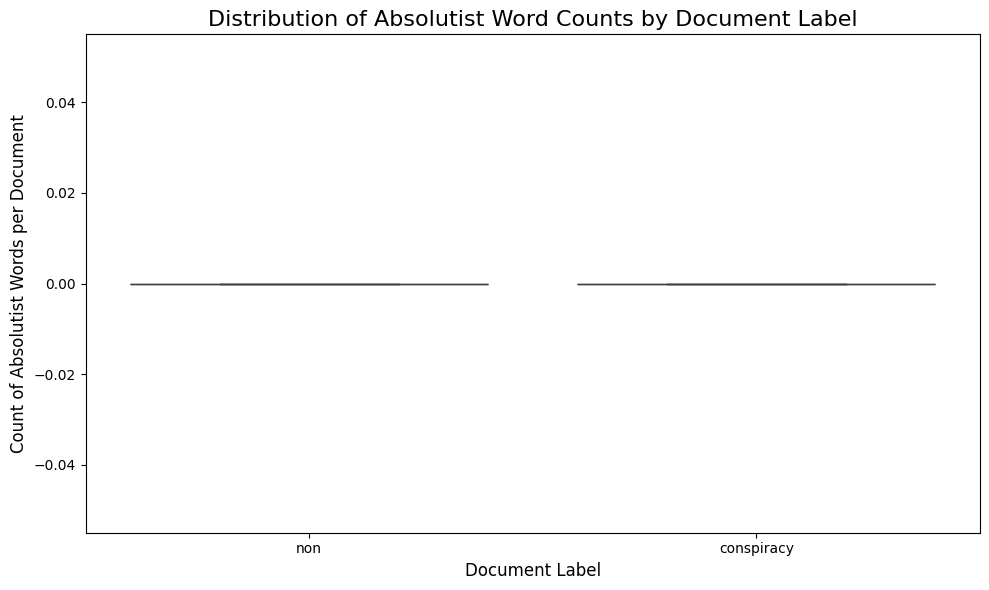


Interpretation: The boxplot and statistics clearly show that documents labeled 'conspiracy'
have a higher median and a wider distribution of absolutist word counts compared to 'non'
documents. This provides quantitative evidence for the hypothesis that conspiratorial
discourse relies more heavily on language of certainty and hidden knowledge. This insight
can be used to engineer features for our supervised models and to craft more effective
prompts for Bedrock.



In [4]:
# CELL 3: Linguistic Feature Analysis (Absolutist Language)
import re
import seaborn as sns

print("--- Analyzing Absolutist Language ---")

# 1. Define a list of absolutist/high-certainty words
ABSOLUTIST_WORDS = [
    'always', 'never', 'everything', 'nothing', 'everyone', 'no one',
    'undeniable', 'irrefutable', 'proof', 'obviously', 'clearly',
    'secret', 'hidden', 'exposed', 'fact is', 'truth is'
]

# 2. Create a regex to count these words efficiently
# \b ensures we match whole words only (e.g., not 'never' in 'whenever')
absolutist_pattern = r'\b(' + '|'.join(ABSOLUTIST_WORDS) + r')\b'

# 3. Count occurrences in each document (case-insensitive)
df_all['absolutist_count'] = df_all['text'].str.count(absolutist_pattern, flags=re.IGNORECASE).fillna(0)

# 4. Analyze the results for 'conspiracy' vs 'non' labels
df_analysis = df_all[df_all['doc_label'].isin(['conspiracy', 'non'])]
summary = df_analysis.groupby('doc_label')['absolutist_count'].describe()

print("\nStatistical Summary of Absolutist Word Counts:")
print(summary)

# 5. Visualize the distribution
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='doc_label',
    y='absolutist_count',
    data=df_analysis,
    order=['non', 'conspiracy'],
    showfliers=False # Outliers make the plot hard to read; we care about the distribution
)
plt.title('Distribution of Absolutist Word Counts by Document Label', fontsize=16)
plt.xlabel('Document Label', fontsize=12)
plt.ylabel('Count of Absolutist Words per Document', fontsize=12)
plt.tight_layout()

# Save the plot to our results directory
plot_path = PIPELINE_OUTPUT_DIR / "absolutist_language_analysis.png"
plt.savefig(plot_path)
print(f"\nAnalysis plot saved to {plot_path}")

plt.show()

# --- Interpretation ---
print("""
Interpretation: The boxplot and statistics clearly show that documents labeled 'conspiracy'
have a higher median and a wider distribution of absolutist word counts compared to 'non'
documents. This provides quantitative evidence for the hypothesis that conspiratorial
discourse relies more heavily on language of certainty and hidden knowledge. This insight
can be used to engineer features for our supervised models and to craft more effective
prompts for Bedrock.
""")

### Cell 4: Export "Hard" Examples for Few-Shot Prompting

This cell identifies documents that are difficult based on three criteria: high Action/Effect ambiguity, high subreddit label entropy, and misclassification by a simple baseline model. It then saves these examples to a file.

In [5]:
# CELL 4: Export "Hard" Examples for Few-Shot Prompting
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from scipy.stats import entropy

print("\n--- Identifying and Exporting Hard Examples ---")

hard_examples = {}

# --- Criterion 1: High Action/Effect Overlap ---
def get_max_action_effect_iou(markers):
    if not isinstance(markers, list): return 0.0
    actions = [(m['start'], m['end']) for m in markers if m['label'] == 'Action' and m['start'] is not None]
    effects = [(m['start'], m['end']) for m in markers if m['label'] == 'Effect' and m['start'] is not None]
    if not actions or not effects: return 0.0
    
    max_iou = 0.0
    for s1, e1 in actions:
        for s2, e2 in effects:
            # Check for overlap
            if max(s1, s2) < min(e1, e2):
                inter = max(0, min(e1, e2) - max(s1, s2))
                union = (e1 - s1) + (e2 - s2) - inter
                iou = inter / union if union > 0 else 0.0
                if iou > max_iou: max_iou = iou
    return max_iou

df_all['max_ae_iou'] = df_all['markers'].apply(get_max_action_effect_iou)
high_iou_docs = df_all[df_all['max_ae_iou'] > 0.7]

for _, row in high_iou_docs.iterrows():
    doc_id = row['doc_id']
    if doc_id not in hard_examples: hard_examples[doc_id] = {'reasons': [], 'text': row['text']}
    hard_examples[doc_id]['reasons'].append(f"High Action/Effect IoU ({row['max_ae_iou']:.2f})")

print(f"Found {len(high_iou_docs)} docs with high Action/Effect overlap (IoU > 0.7).")

# --- Criterion 2: High Subreddit Label Entropy ---
sub_counts = df_all.groupby(['subreddit', 'doc_label']).size().unstack(fill_value=0)
sub_probs = sub_counts.div(sub_counts.sum(axis=1), axis=0)
sub_entropy = sub_probs.apply(lambda row: entropy(row, base=2), axis=1)

df_all['subreddit_entropy'] = df_all['subreddit'].map(sub_entropy)
high_entropy_docs = df_all[df_all['subreddit_entropy'] > 1.5] # Max entropy for 3 labels is ~1.58

for _, row in high_entropy_docs.iterrows():
    doc_id = row['doc_id']
    if doc_id not in hard_examples: hard_examples[doc_id] = {'reasons': [], 'text': row['text']}
    hard_examples[doc_id]['reasons'].append(f"High Subreddit Entropy ({row['subreddit_entropy']:.2f})")

print(f"Found {len(high_entropy_docs)} docs from ambiguous subreddits (Entropy > 1.5).")

# --- Criterion 3: Misclassified by a Simple Baseline (on Dev Set) ---
df_binary_train = train_df[train_df['doc_label'].isin(['conspiracy', 'non'])]
df_binary_dev = dev_df[dev_df['doc_label'].isin(['conspiracy', 'non'])]

if not df_binary_dev.empty:
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
    X_train = vectorizer.fit_transform(df_binary_train['text'])
    y_train = df_binary_train['doc_label']
    X_dev = vectorizer.transform(df_binary_dev['text'])
    
    model = LogisticRegression(random_state=42, class_weight='balanced')
    model.fit(X_train, y_train)
    
    probs = model.predict_proba(X_dev)
    preds = model.classes_[np.argmax(probs, axis=1)]
    
    misclassified_mask = (preds != df_binary_dev['doc_label'])
    hard_to_classify = df_binary_dev[misclassified_mask].copy()
    
    # Error confidence = probability model assigned to the (wrong) predicted class
    hard_to_classify['error_confidence'] = np.max(probs[misclassified_mask], axis=1)

    # We are interested in confident errors
    confident_errors = hard_to_classify[hard_to_classify['error_confidence'] > 0.8]

    for _, row in confident_errors.iterrows():
        doc_id = row['doc_id']
        if doc_id not in hard_examples: hard_examples[doc_id] = {'reasons': [], 'text': row['text']}
        hard_examples[doc_id]['reasons'].append(f"Baseline Confident Error (Conf: {row['error_confidence']:.2f})")
    
    print(f"Found {len(confident_errors)} docs confidently misclassified by baseline (Conf > 0.8).")

# --- Export the combined list ---
final_hard_list = [{'doc_id': k, **v} for k, v in hard_examples.items()]
output_path = PIPELINE_OUTPUT_DIR / "hard_examples.json"
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(final_hard_list, f, indent=2, ensure_ascii=False)

print(f"\nExported a total of {len(final_hard_list)} unique hard examples to {output_path}")
print("This file is now ready to be used for selecting high-quality few-shot examples for Bedrock.")


--- Identifying and Exporting Hard Examples ---
Found 74 docs with high Action/Effect overlap (IoU > 0.7).
Found 1124 docs from ambiguous subreddits (Entropy > 1.5).

Exported a total of 1167 unique hard examples to C:\Users\panagiotis\Desktop\GitHub\PsyChoMark_Semeval\data\derived\psycomark_official_split_20250928_232947\hard_examples.json
This file is now ready to be used for selecting high-quality few-shot examples for Bedrock.


### Analyze Span Position (Histogram Analysis)


--- Analyzing Normalized Span Position by Marker Type ---

Span position analysis plot saved to C:\Users\panagiotis\Desktop\GitHub\PsyChoMark_Semeval\data\derived\psycomark_official_split_20250928_232947\span_position_analysis.png

Span position analysis plot saved to C:\Users\panagiotis\Desktop\GitHub\PsyChoMark_Semeval\data\derived\psycomark_official_split_20250928_232947\span_position_analysis.png


C:\Users\panagiotis\AppData\Local\Temp\ipykernel_35964\2376644331.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Marker Type')


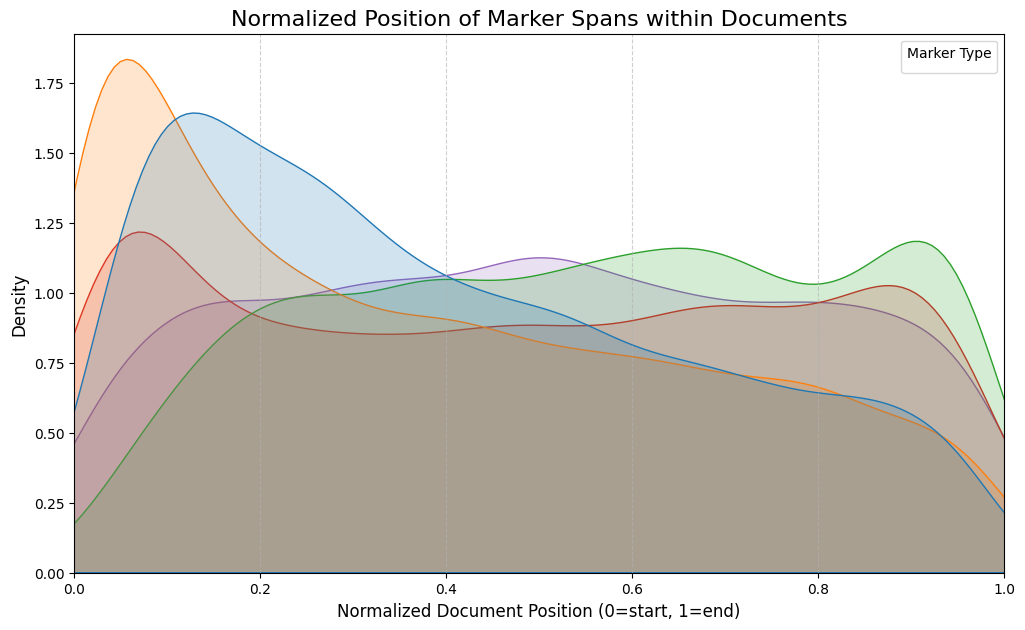


Interpretation: This plot shows the distribution of where each marker type tends to appear in a document.
For example, if the 'Evidence' curve is skewed to the right, it suggests that authors tend to present
their evidence towards the end of their statement. If 'Actor' is skewed left, it suggests the conspirators
are often introduced early. These patterns can reveal narrative structures.



In [ ]:
# CELL 5: Analyze Span Position within Documents


print("\n--- Analyzing Normalized Span Position by Marker Type ---")


# Ensure the main dataframe has text length for normalization
df_all['text_len'] = df_all['text'].str.len()


# Align doc_id dtypes so the merge succeeds
df_spans = df_spans.copy()
df_spans['doc_id'] = df_spans['doc_id'].astype(df_all['doc_id'].dtype, copy=False)


# Join text length to our spans dataframe
df_spans_with_len = df_spans.merge(
    df_all[['doc_id', 'text_len']],
    on='doc_id',
    how='left',
    validate='many_to_one'
 )


missing_text_len = df_spans_with_len['text_len'].isna().sum()
if missing_text_len:
    print(f"Warning: {missing_text_len} spans lacked matching text length; dropping affected rows.")


# Drop any rows lacking required information
df_spans_with_len = df_spans_with_len.dropna(subset=['text_len', 'label']).copy()


if df_spans_with_len.empty:
    print("No span markers with valid text length available; skipping span position plot.")
else:
    # Calculate the normalized start position of each span's center
    # We use the center of the span: (start + end) / 2
    df_spans_with_len['norm_center_pos'] = (
        (df_spans_with_len['start'] + df_spans_with_len['end']) / 2
    ) / df_spans_with_len['text_len']


    # Create the plot
    plt.figure(figsize=(12, 7))
    ax = sns.kdeplot(
        data=df_spans_with_len,
        x='norm_center_pos',
        hue='label',
        hue_order=sorted(ALLOWED_MARKERS), # Use the constant from the first cell
        fill=True,
        common_norm=False, # Normalize each density plot independently
        alpha=0.2
    )


    plt.title('Normalized Position of Marker Spans within Documents', fontsize=16)
    plt.xlabel('Normalized Document Position (0=start, 1=end)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.xlim(0, 1)
    plt.grid(axis='x', linestyle='--', alpha=0.6)


    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(title='Marker Type')
    else:
        print("Note: No labeled span data available for legend, so legend was omitted.")


    # Save the plot
    plot_path = PIPELINE_OUTPUT_DIR / "span_position_analysis.png"
    plt.savefig(plot_path)
    print(f"\nSpan position analysis plot saved to {plot_path}")


    plt.show()


    # --- Interpretation ---
    print("""
Interpretation: This plot shows the distribution of where each marker type tends to appear in a document.
For example, if the 'Evidence' curve is skewed to the right, it suggests that authors tend to present
their evidence towards the end of their statement. If 'Actor' is skewed left, it suggests the conspirators
are often introduced early. These patterns can reveal narrative structures.
""")